In [1]:
import pandas as pd

In [2]:
reloc = pd.read_csv("../data/manipulated/compiled_analysis_data.csv")
reloc["Timestamp"] = pd.to_datetime(reloc["Timestamp"])

In [3]:
reloc["date"] = reloc["Timestamp"].dt.date
reloc["hour"] = reloc["Timestamp"].dt.floor("h")

In [4]:
reloc = reloc.drop_duplicates(["ID", "hour"], keep = "first")

In [5]:
# 1) How many observations do we have per day?
daily_fixes = reloc.groupby(["date", "ID"]).size().rename("count")
full_dates = pd.date_range("2024-11-01", "2025-10-31", freq="D")
all_ids = reloc["ID"].unique()
full_index = pd.MultiIndex.from_product(
    [full_dates, all_ids],
    names=["date", "ID"]
)
daily_fixes = (
    daily_fixes
    .reindex(full_index, fill_value=0)
    .reset_index()
)

In [6]:
active_period = (
    reloc
    .groupby("ID")["date"]
    .agg(start="min", end="max")
    .reset_index()
)

daily_fixes = daily_fixes.merge(active_period, on="ID", how="left")

daily_fixes = daily_fixes[
    (daily_fixes["date"] >= daily_fixes["start"]) &
    (daily_fixes["date"] <= daily_fixes["end"])
].copy()

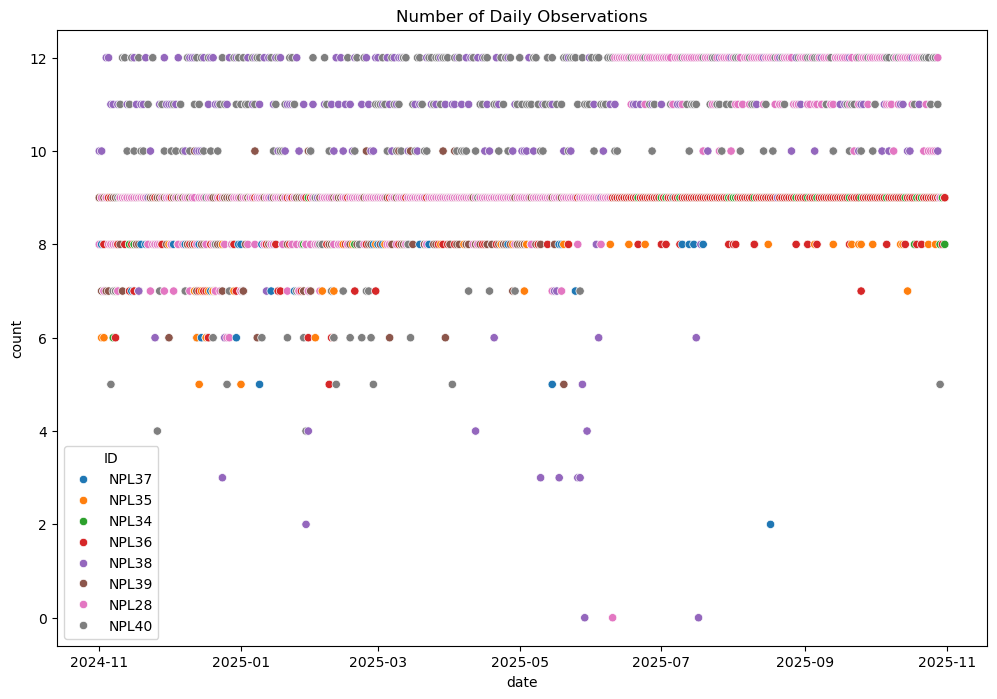

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize = (12, 8))
sns.scatterplot(daily_fixes, x = "date", y = "count", hue = "ID")
plt.title("Number of Daily Observations")
plt.show()

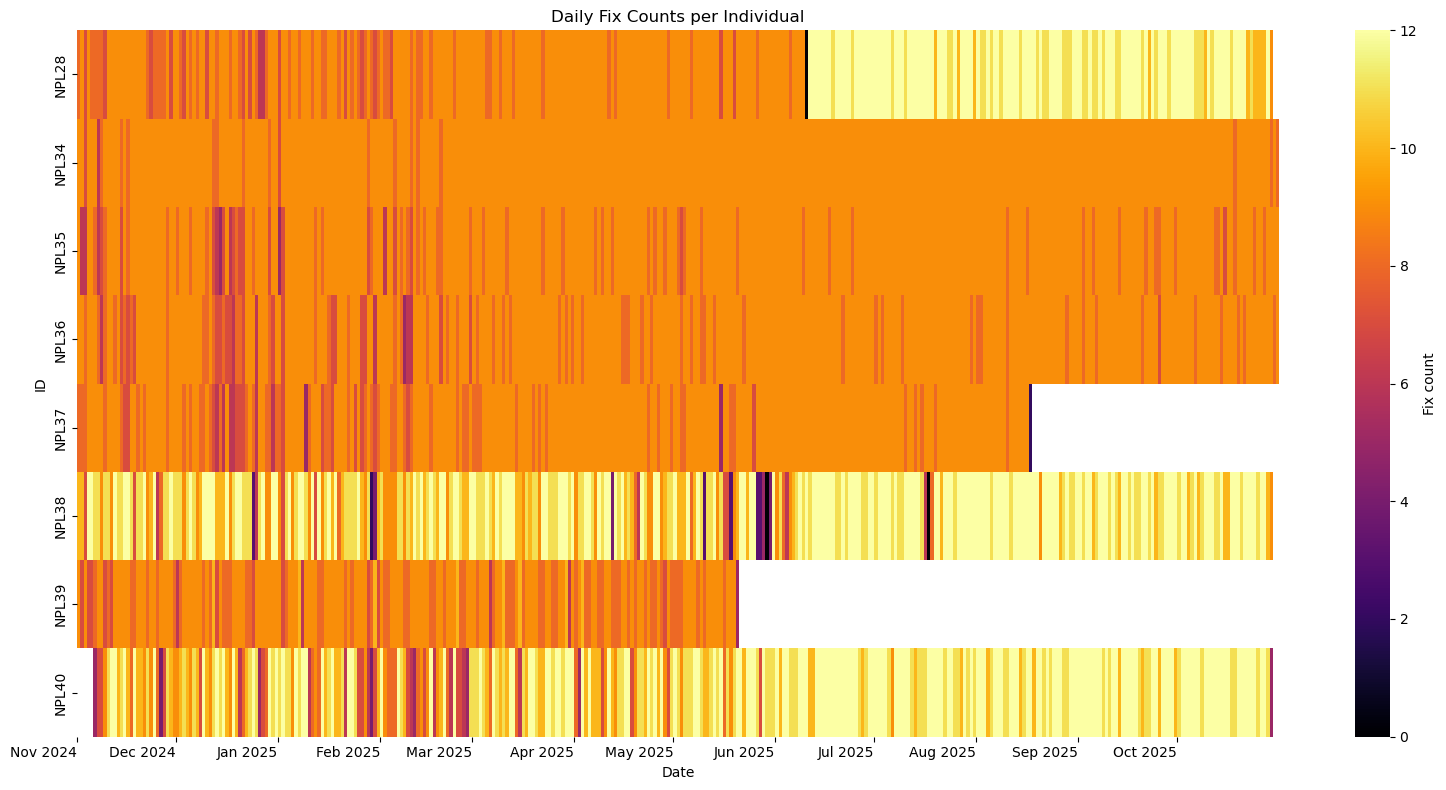

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

pivot = daily_fixes.pivot(index="ID", columns="date", values="count")

fig, ax = plt.subplots(figsize = (16, 8))
sns.heatmap(pivot, cmap="inferno", cbar_kws={"label": "Fix count"}, ax = ax)
month_starts = [i for i, d in enumerate(pivot.columns) if d.day == 1]

ax.set_xticks(month_starts)
ax.set_xticklabels(
    [pivot.columns[i].strftime("%b %Y") for i in month_starts],
    rotation=0,
    ha="right"
)

ax.set_xlabel("Date")
ax.set_ylabel("ID")
ax.set_title("Daily Fix Counts per Individual")

plt.tight_layout()
plt.show()

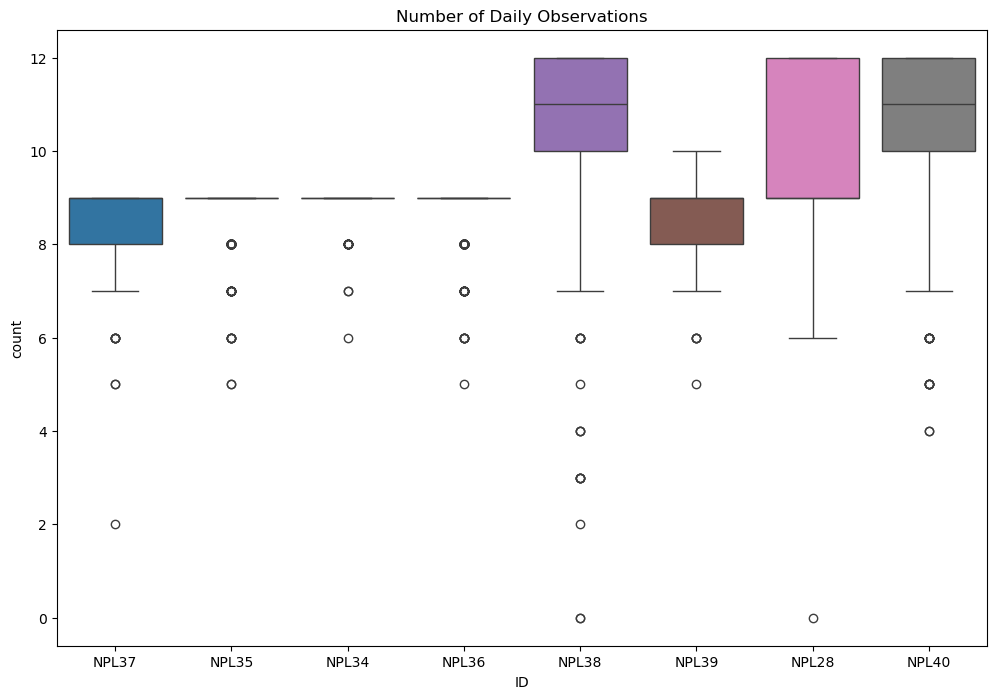

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize = (12, 8))
sns.boxplot(daily_fixes, x = "ID", y = "count", hue = "ID")
plt.title("Number of Daily Observations")
plt.show()

In [10]:
reloc = reloc.sort_values(["ID", "Timestamp"])
reloc["previous_timestamp"] = reloc.groupby("ID")["Timestamp"].shift(1)

In [11]:
reloc["t_diff_h"] = (reloc["Timestamp"] - reloc["previous_timestamp"]).dt.seconds / 60 / 60

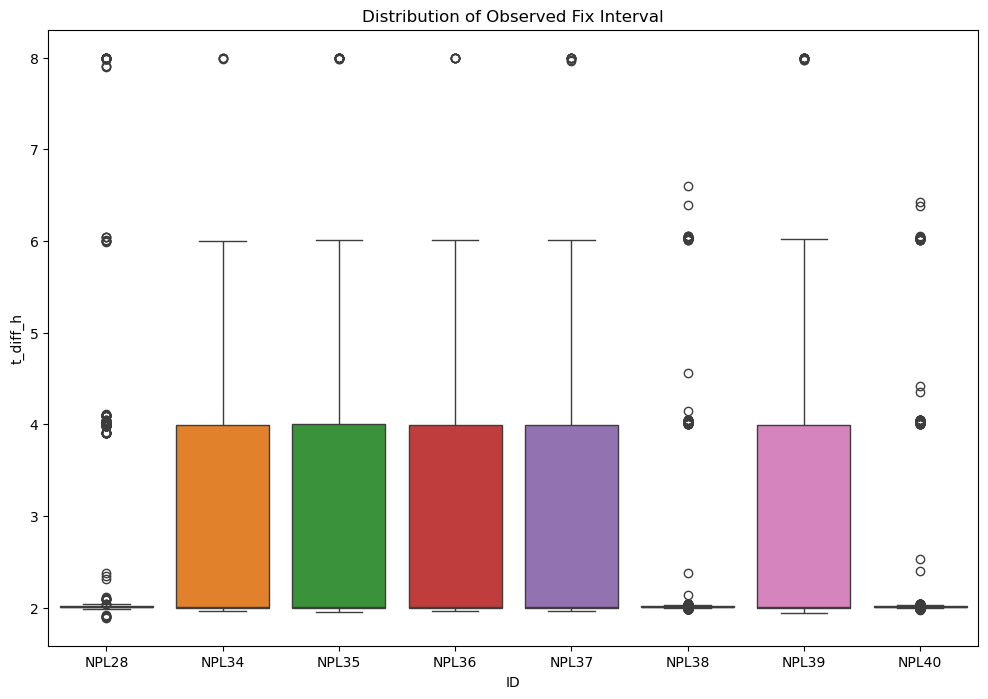

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize = (12, 8))
sns.boxplot(reloc[reloc["t_diff_h"] < 8], x = "ID", y = "t_diff_h", hue = "ID")
plt.title("Distribution of Observed Fix Interval")
plt.show()

### Spatial Distribution

In [13]:
import geopandas as gpd
reloc_gdf = gpd.GeoDataFrame(reloc, geometry = gpd.points_from_xy(reloc["Longitude"], reloc["Latitude"]), crs = 4326)
reloc_gdf = reloc_gdf.to_crs("EPSG:32733")

In [14]:
reloc_gdf = reloc_gdf[~((reloc_gdf["ID"] == "NPL39") & (reloc_gdf["Timestamp"] > "2025-05-19 20:00:52+00:00"))]

In [15]:
import hvplot, hvplot.pandas
reloc_gdf.to_crs(4326).hvplot(geo = True, by = "ID", tiles = "OSM", width = 1200, height = 800)

:Overlay
   .WMTS.I      :WMTS   [Longitude,Latitude]
   .NdOverlay.I :NdOverlay   [ID]
      :Points   [Longitude,Latitude]

In [16]:
first_points = (
    reloc_gdf
    .sort_values(["ID", "Timestamp"])
    .drop_duplicates("ID", keep="first")
)[["ID", "geometry"]].rename(columns = {"geometry": "first_point"})

In [17]:
reloc_gdf = reloc_gdf.merge(first_points, on = "ID")

In [18]:
reloc_gdf["displacement"] = reloc_gdf.geometry.distance(reloc_gdf["first_point"]) / 1000

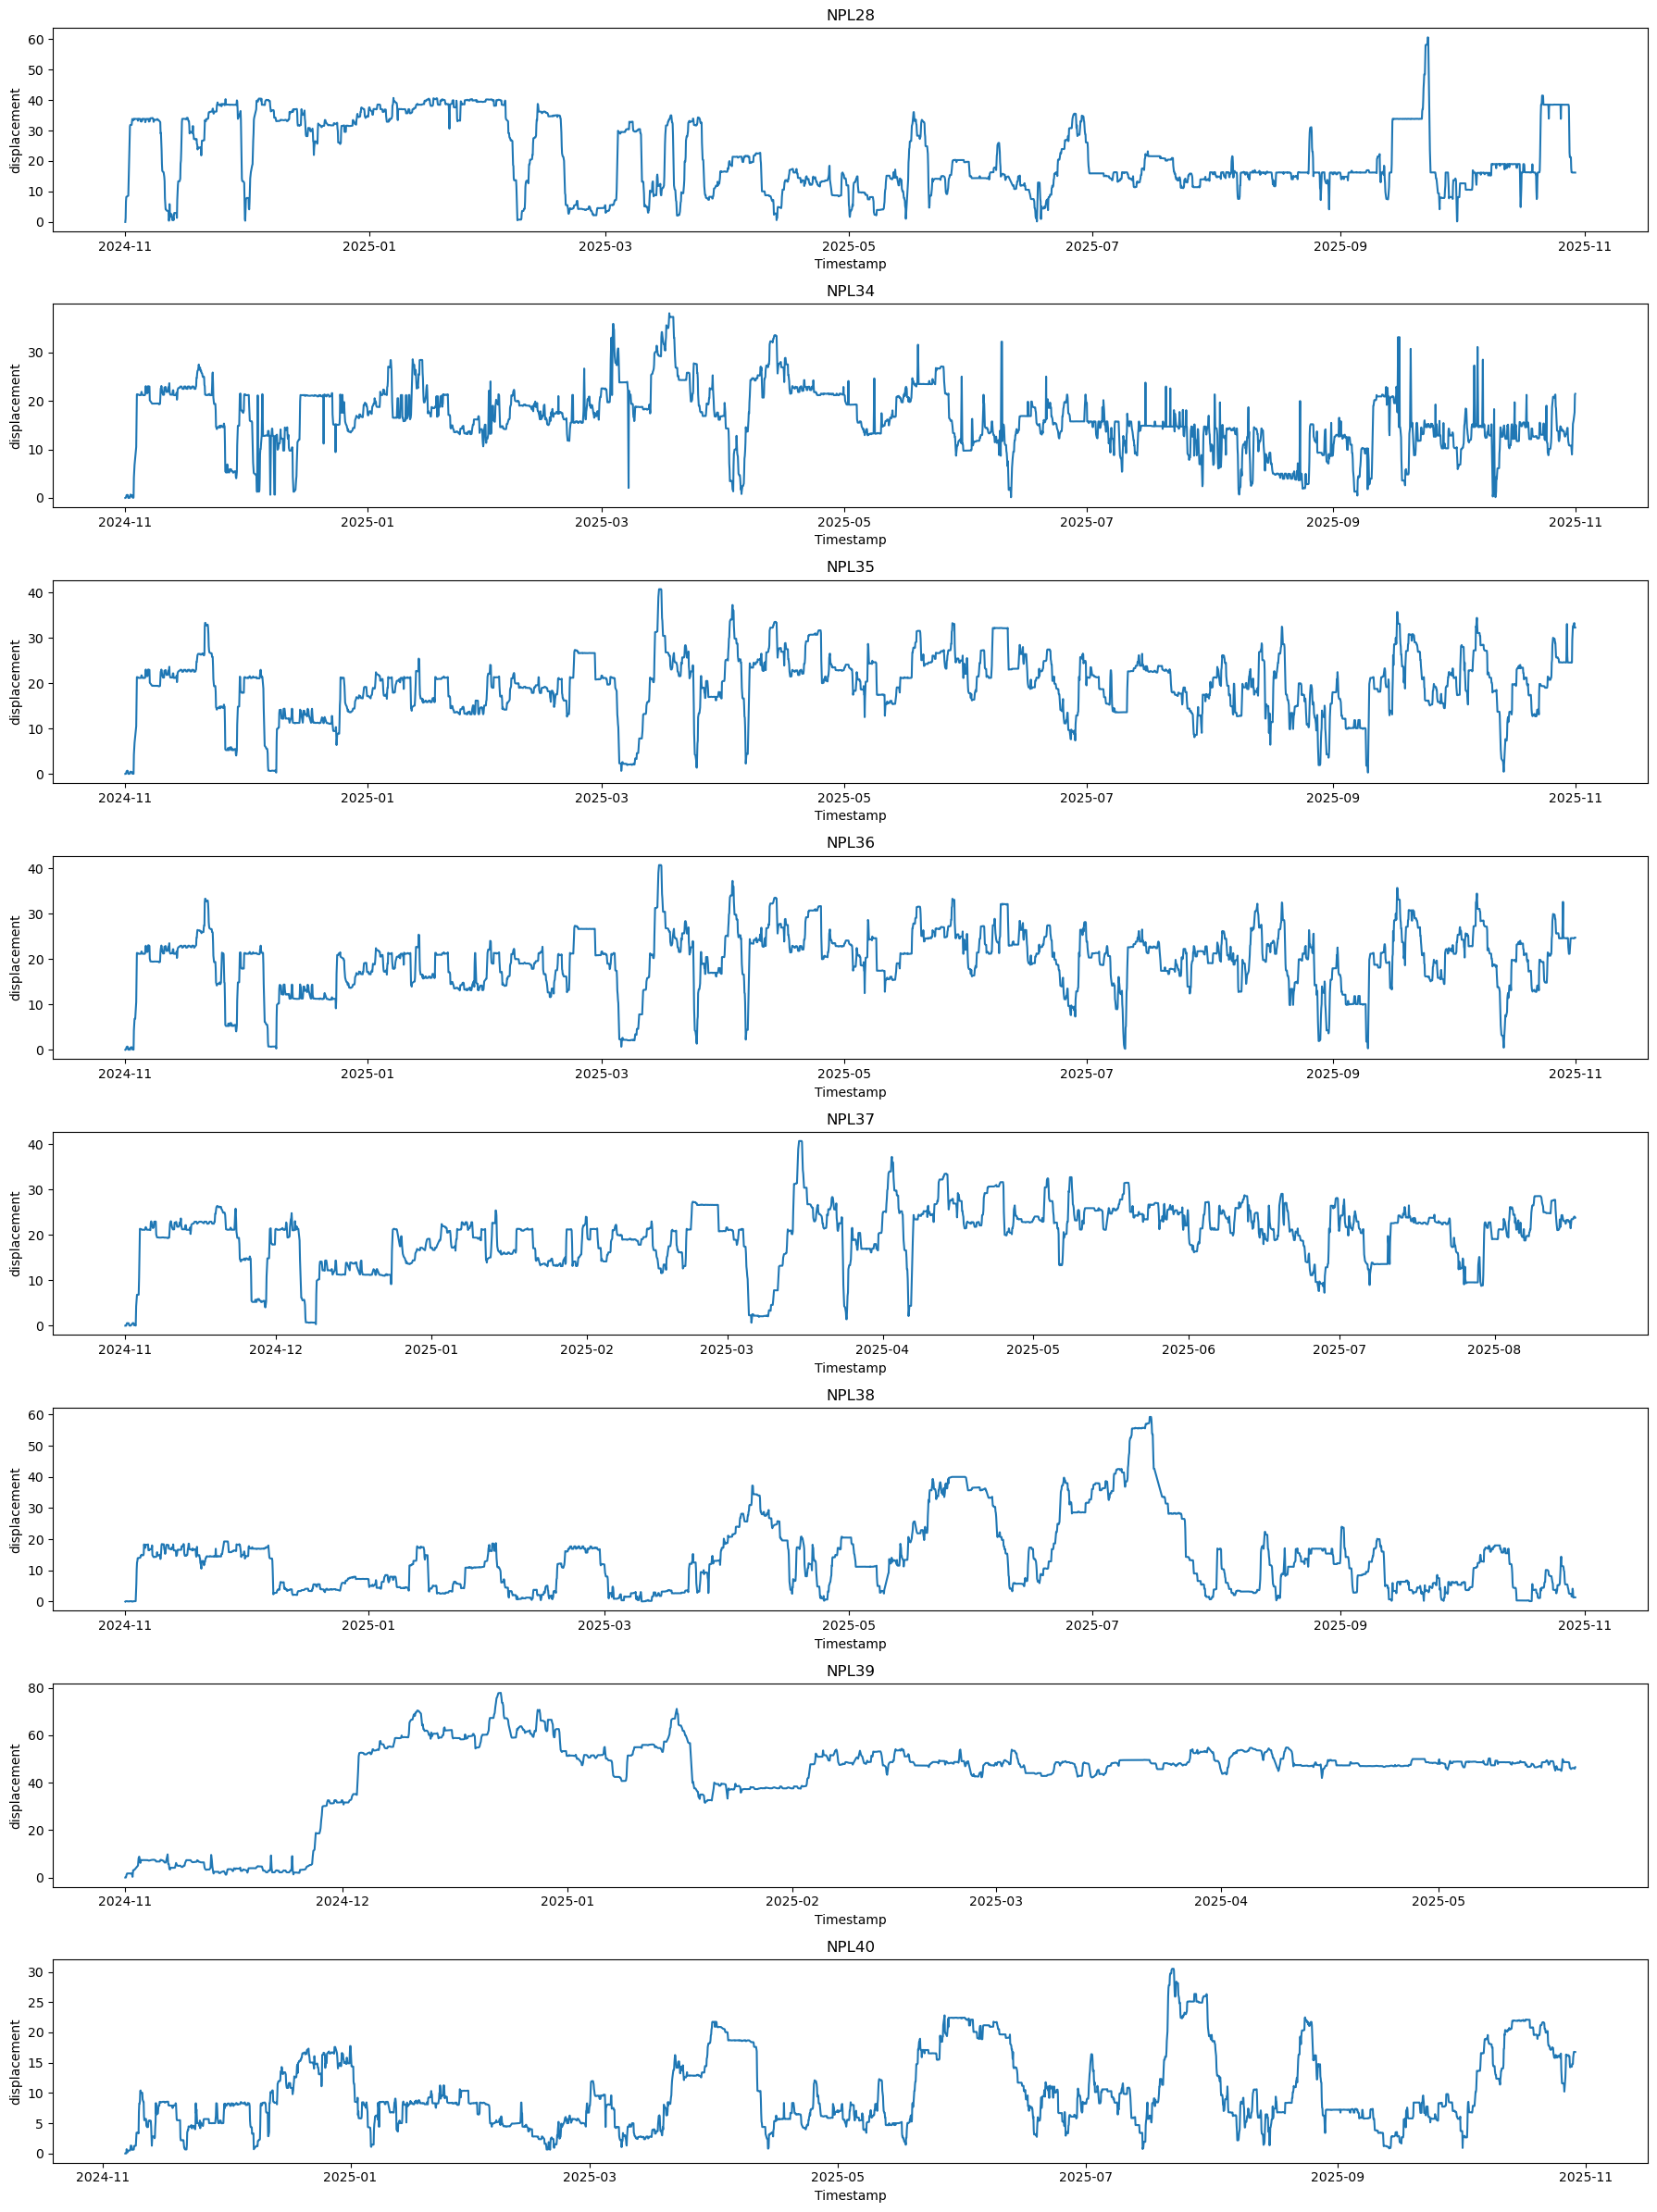

In [19]:
fig, axes = plt.subplots(figsize = (18, 24), nrows = len(reloc_gdf["ID"].unique()))

for i, id in enumerate(reloc_gdf["ID"].unique()):
    sns.lineplot(reloc_gdf[reloc_gdf["ID"] == id], x = "Timestamp", y = "displacement", ax = axes[i])
    axes[i].set_title(id)

plt.tight_layout()
plt.show()

In [20]:
reloc = reloc.sort_values(["ID", "Timestamp"])
reloc_gdf["previous_location"] = reloc_gdf.groupby("ID")["geometry"].shift(1)
reloc_gdf["distance_previous_location_km"] = reloc_gdf.geometry.distance(reloc_gdf["previous_location"]) / 1000
reloc_gdf["speed_kmh"] = reloc_gdf["distance_previous_location_km"] / reloc_gdf["t_diff_h"]

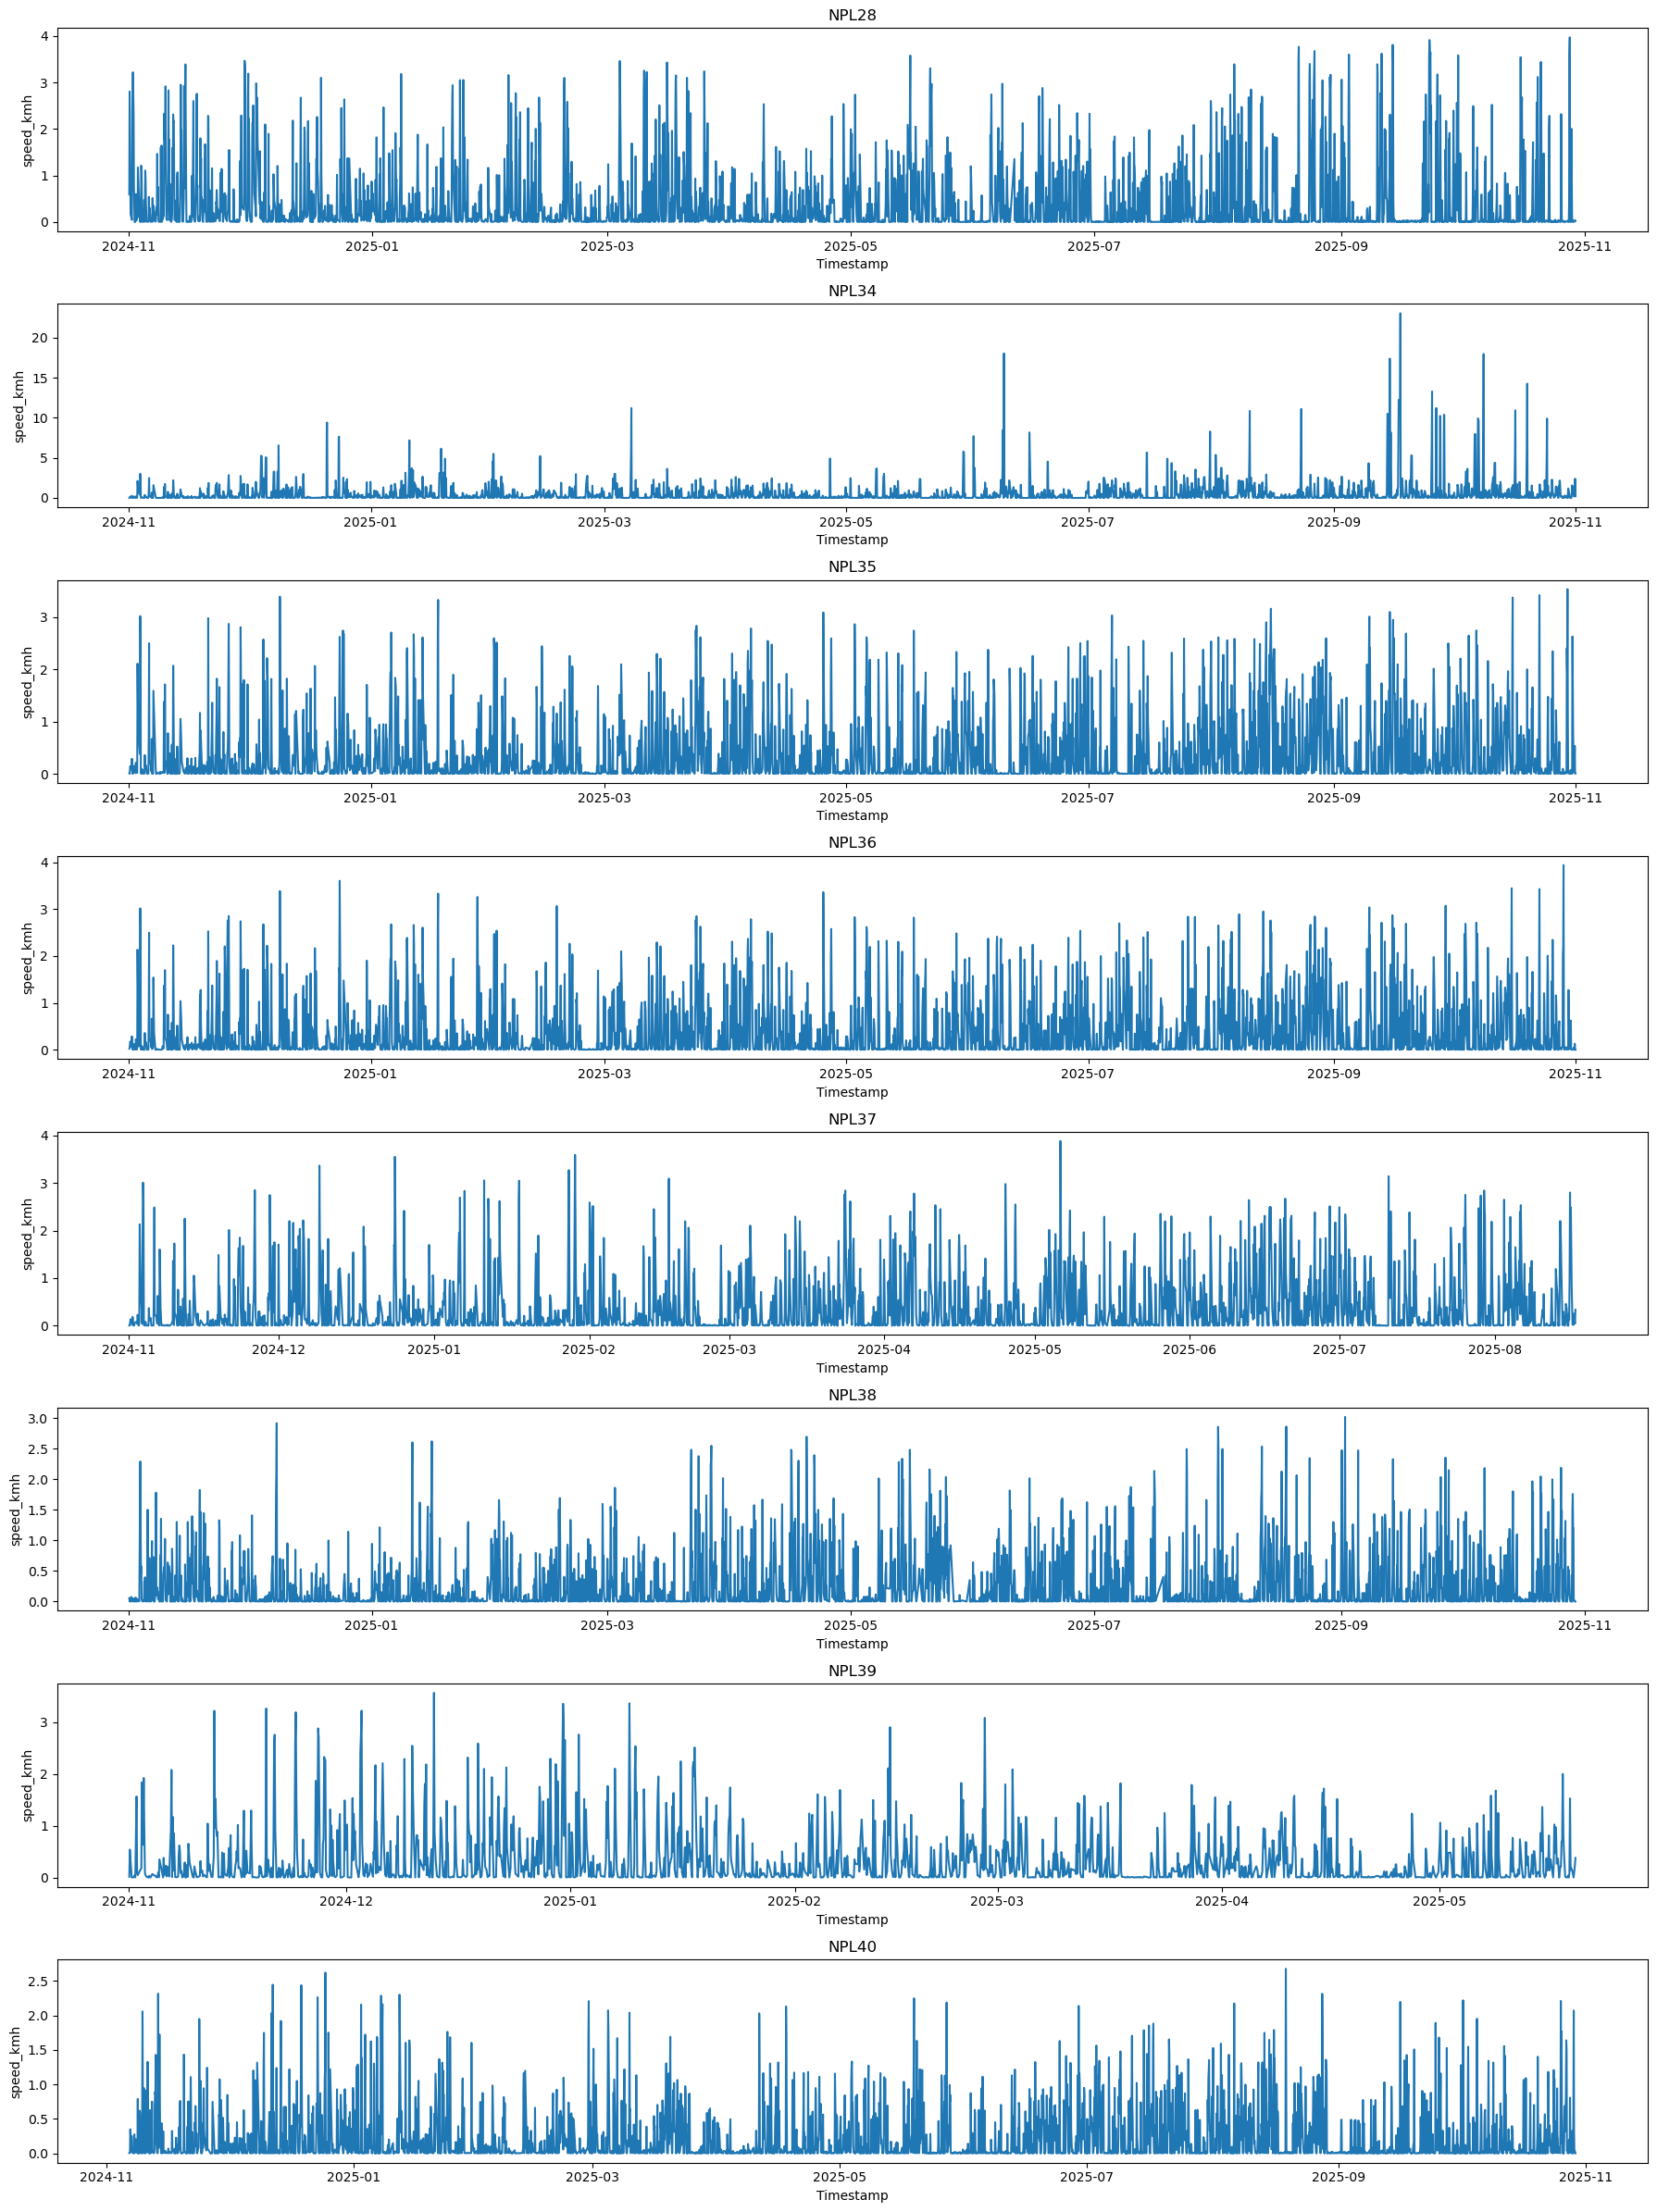

In [21]:
fig, axes = plt.subplots(figsize = (18, 24), nrows = len(reloc_gdf["ID"].unique()))

for i, id in enumerate(reloc_gdf["ID"].unique()):
    sns.lineplot(reloc_gdf[reloc_gdf["ID"] == id], x = "Timestamp", y = "speed_kmh", ax = axes[i])
    axes[i].set_title(id)

plt.tight_layout()
plt.show()

In [22]:
reloc_gdf.to_csv("../data/manipulated/all_for_gis.csv")

### Basic Movement Metrics

In [23]:
correct_steps = reloc_gdf.copy()
correct_steps["t_diff_min"] = correct_steps["t_diff_h"] * 60

In [24]:
correct_steps = correct_steps[(correct_steps["t_diff_min"] > 118) & (correct_steps["t_diff_min"] < 122)]

In [25]:
correct_steps["step_m"] = correct_steps["distance_previous_location_km"] * 1000

In [26]:
correct_steps.sort_values("step_m", ascending=False).head(10)

,Timestamp,Latitude,Longitude,ID,source,hour,date,previous_timestamp,t_diff_h,geometry,first_point,displacement,previous_location,distance_previous_location_km,speed_kmh,t_diff_min,step_m
6409,2025-09-17 18:00:35+00:00,-19.284660,14.184789,NPL34,rest,2025-09-17 18:00:00+00:00,2025-09-17,2025-09-17 16:00:37+00:00,1.999444,POINT (414343.780 7867473.765),POINT (403154.333 7858172.492),14.550512,POINT (392935.883 7826683.469),46.066758,23.039779,119.966667,46066.758181
5509,2025-06-09 18:00:11+00:00,-19.318327,13.979656,NPL34,rest,2025-06-09 18:00:00+00:00,2025-06-09,2025-06-09 16:00:09+00:00,2.000556,POINT (392810.334 7863633.999),POINT (403154.333 7858172.492),11.697281,POINT (393291.324 7827561.022),36.076184,18.033083,120.033333,36076.183771
6598,2025-10-08 18:00:10+00:00,-19.309488,13.953442,NPL34,rest,2025-10-08 18:00:00+00:00,2025-10-08,2025-10-08 16:00:11+00:00,1.999722,POINT (390050.277 7864595.702),POINT (403154.333 7858172.492),14.593626,POINT (399473.708 7829948.636),35.905713,17.955351,119.983333,35905.713423
6386,2025-09-15 02:00:10+00:00,-19.470020,13.998060,NPL34,rest,2025-09-15 02:00:00+00:00,2025-09-15,2025-09-15 00:00:11+00:00,1.999722,POINT (394841.345 7846858.052),POINT (403154.333 7858172.492),14.040026,POINT (418703.810 7872105.175),34.739523,17.372174,119.983333,34739.522583
6696,2025-10-19 18:00:13+00:00,-19.309486,13.953345,NPL34,rest,2025-10-19 18:00:00+00:00,2025-10-19,2025-10-19 16:01:27+00:00,1.979444,POINT (390040.155 7864595.852),POINT (403154.333 7858172.492),14.602781,POINT (398088.072 7837571.555),28.197192,14.245003,118.766667,28197.191507
6481,2025-09-25 18:00:15+00:00,-19.308495,13.952482,NPL34,rest,2025-09-25 18:00:00+00:00,2025-09-25,2025-09-25 16:00:11+00:00,2.001111,POINT (389948.810 7864705.065),POINT (403154.333 7858172.492),14.732968,POINT (405336.932 7843040.606),26.573353,13.279299,120.066667,26573.352941
4663,2025-03-07 18:00:37+00:00,-19.566708,14.056595,NPL34,rest,2025-03-07 18:00:00+00:00,2025-03-07,2025-03-07 16:00:10+00:00,2.007500,POINT (401044.190 7836192.810),POINT (403154.333 7858172.492),22.080741,POINT (401155.537 7858684.306),22.491772,11.203871,120.450000,22491.771508
6491,2025-09-26 20:00:33+00:00,-19.326056,13.965582,NPL34,rest,2025-09-26 20:00:00+00:00,2025-09-26,2025-09-26 18:00:38+00:00,1.998611,POINT (391336.775 7862769.937),POINT (403154.333 7858172.492),12.680346,POINT (395154.445 7840676.701),22.420653,11.218117,119.916667,22420.653064
6490,2025-09-26 18:00:38+00:00,-19.525890,14.000700,NPL34,rest,2025-09-26 18:00:00+00:00,2025-09-26,2025-09-26 16:00:15+00:00,2.006389,POINT (395154.445 7840676.701),POINT (403154.333 7858172.492),19.238007,POINT (391371.496 7862710.618),22.356301,11.142556,120.383333,22356.301464
6184,2025-08-23 18:00:11+00:00,-19.339884,14.058796,NPL34,rest,2025-08-23 18:00:00+00:00,2025-08-23,2025-08-23 16:00:10+00:00,2.000278,POINT (401137.743 7861295.530),POINT (403154.333 7858172.492),3.717526,POINT (395037.006 7839943.373),22.206612,11.101764,120.016667,22206.611653


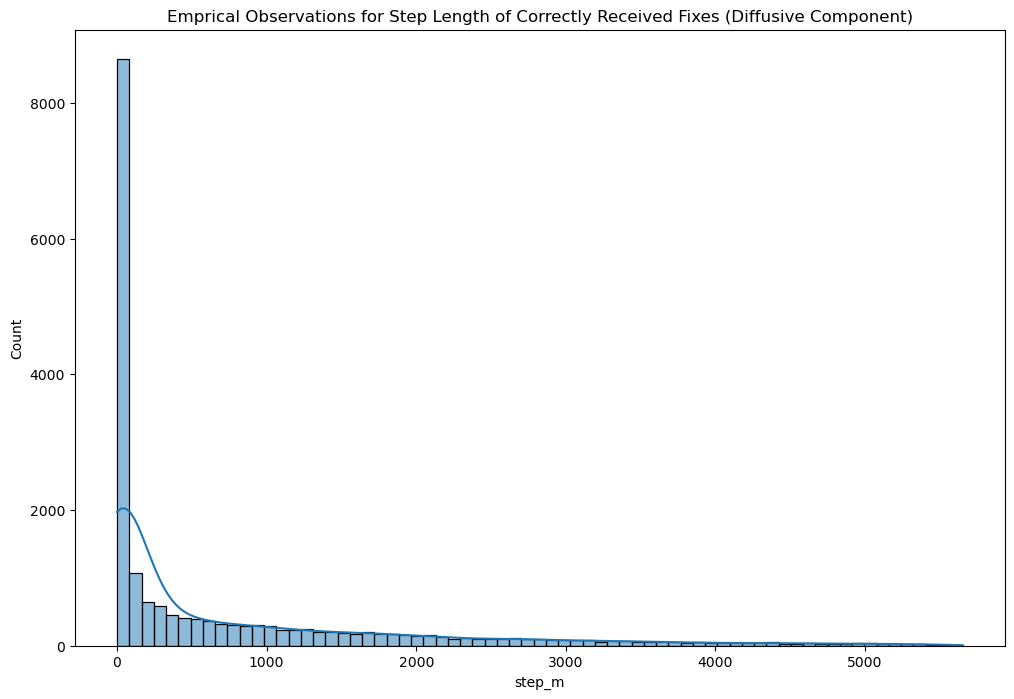

In [27]:
import numpy as np
fig, ax = plt.subplots(figsize = (12, 8))
sns.histplot(correct_steps[correct_steps["step_m"] < np.nanquantile(correct_steps["step_m"], .99)], x = "step_m", kde = True)
plt.title("Emprical Observations for Step Length of Correctly Received Fixes (Diffusive Component)")
plt.show()

c:\Users\paulk\anaconda3\envs\africat-env\Lib\site-packages\scipy\stats\_continuous_distns.py:2757: RuntimeWarning: divide by zero encountered in power
  return c*pow(x, c-1)*np.exp(-pow(x, c))


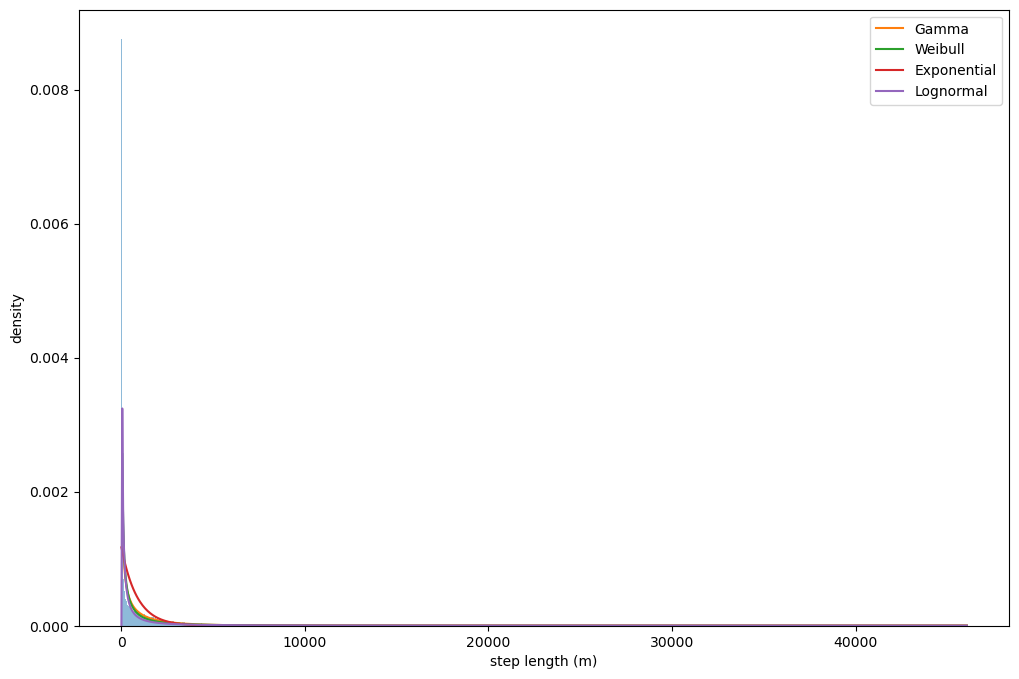

In [28]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

x = correct_steps["step_m"].values
x = x[x > 0]  # remove zeros if needed
# Fit distributions
gamma_params = stats.gamma.fit(x, floc=0)
weibull_params = stats.weibull_min.fit(x, floc=0)
exp_params = stats.expon.fit(x, floc=0)
lognorm_params = stats.lognorm.fit(x, floc=0)

# Generate x for plotting
xx = np.linspace(0, x.max(), 1000)

# PDFs
gamma_pdf = stats.gamma.pdf(xx, *gamma_params)
weibull_pdf = stats.weibull_min.pdf(xx, *weibull_params)
exp_pdf = stats.expon.pdf(xx, *exp_params)
lognorm_pdf = stats.lognorm.pdf(xx, *lognorm_params)

# Plot
fig, ax = plt.subplots(figsize = (12, 8))
ax.hist(x, bins = 1000, density=True, alpha=0.5)
ax.plot(xx, gamma_pdf, label="Gamma")
ax.plot(xx, weibull_pdf, label="Weibull")
ax.plot(xx, exp_pdf, label="Exponential")
ax.plot(xx, lognorm_pdf, label="Lognormal")

plt.legend()
plt.xlabel("step length (m)")
plt.ylabel("density")
plt.show()

In [29]:
def aic(loglik, k):
    return 2*k - 2*loglik

models = {
    "gamma": (stats.gamma, gamma_params),
    "weibull": (stats.weibull_min, weibull_params),
    "exp": (stats.expon, exp_params),
    "lognorm": (stats.lognorm, lognorm_params),
}

results = []

for name, (dist, params) in models.items():
    loglik = np.sum(dist.logpdf(x, *params))
    k = len(params)
    results.append({"Distribution": name, "params": params, "AIC": aic(loglik, k)})

results = pd.DataFrame(results)

In [30]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt


def aic(loglik, k):
    return 2 * k - 2 * loglik


def estimate_diff_distribution(id, steps, cutoff, bins=50, plot = False, plot_all=False):
    # clean data
    steps = pd.Series(steps).dropna()
    steps = steps[(steps > 0) & (steps <= cutoff)].to_numpy()

    if len(steps) == 0:
        raise ValueError("No positive step lengths remaining after applying cutoff.")

    # fit candidate distributions
    gamma_params = stats.gamma.fit(steps, floc=0)
    weibull_params = stats.weibull_min.fit(steps, floc=0)
    exp_params = stats.expon.fit(steps, floc=0)
    lognorm_params = stats.lognorm.fit(steps, floc=0)

    models = {
        "gamma": (stats.gamma, gamma_params),
        "weibull": (stats.weibull_min, weibull_params),
        "exp": (stats.expon, exp_params),
        "lognorm": (stats.lognorm, lognorm_params),
    }

    results = []

    for name, (dist, params) in models.items():
        loglik = np.sum(dist.logpdf(steps, *params))
        k = len(params)
        results.append({
            "Distribution": name,
            "params": params,
            "AIC": aic(loglik, k)
        })

    results = pd.DataFrame(results).sort_values("AIC").reset_index(drop=True)
    winner = results.loc[0]

    if plot: 
        # plotting grid
        xx = np.linspace(0, steps.max(), 1000)

        fig, ax = plt.subplots(figsize=(12, 8))

        # observed distribution
        ax.hist(
            steps,
            bins=bins,
            density=True,
            alpha=0.5,
            edgecolor="black",
            label="Observed"
        )

        # plot winner only or all candidates

        if plot_all:
            for name, (dist, params) in models.items():
                yy = dist.pdf(xx, *params)
                ax.plot(xx, yy, lw=2, label=name)
        else:
            best_name = winner["Distribution"]
            best_dist, best_params = models[best_name]
            yy = best_dist.pdf(xx, *best_params)
            ax.plot(xx, yy, lw=3, label=f"Best fit: {best_name}")

        ax.set_xlabel("Step length")
        ax.set_ylabel("Density")
        ax.set_title("Fitted step-length distribution")
        ax.legend()
        plt.show()

    results = {
        "ID": id,
        "q25": np.nanquantile(steps, 0.25),
        "median": np.nanmedian(steps),
        "mean": np.nanmean(steps),
        "q75": np.nanquantile(steps, 0.75),
        "max": np.nanmax(steps),
        "distribution": winner["Distribution"],
        "params": winner["params"]
    }
    return results

In [31]:
per_individual = []
for id, subset in correct_steps.groupby("ID"):
    results  = estimate_diff_distribution(id, subset["step_m"].values, 20_000)
    per_individual.append(results)

In [32]:
print(pd.DataFrame(per_individual))

      ID        q25      median         mean          q75           max  \
0  NPL28   9.415090  114.881007   971.067935  1360.639121   7949.905957   
1  NPL34  18.623272  279.345894  1053.335483  1407.701429  19806.298421   
2  NPL35  18.596011  358.936334  1081.158303  1730.960975   7050.967466   
3  NPL36  19.062458  370.726369  1071.553150  1694.074594   7847.132963   
4  NPL37  17.568220  375.701548  1062.500878  1650.254772   7777.741436   
5  NPL38   8.041519   49.425504   523.098114   668.082784   6079.707070   
6  NPL39  35.094791  474.539919   935.475919  1394.609639   6785.875187   
7  NPL40   9.472123   48.675059   476.051129   648.826686   5376.684489   

  distribution                                       params  
0      lognorm   (2.624413081022504, 0, 112.30787315017783)  
1      weibull  (0.49317849157882987, 0, 543.3342221285454)  
2        gamma  (0.37222838859631074, 0, 2904.556278968983)  
3        gamma   (0.3786545371577004, 0, 2829.896501154465)  
4        gamma

### Advective Component

In [33]:
correct_steps = correct_steps.copy()
correct_steps["t_next_fix"] = correct_steps.groupby("ID")["Timestamp"].shift(-1)
correct_steps["t_diff_next_fix_min"] = (correct_steps["t_next_fix"] - correct_steps["Timestamp"]).dt.seconds / 60
correct_steps["next_position"] = correct_steps.groupby("ID")["geometry"].shift(-1)

In [34]:
correct_angles = correct_steps.copy()
correct_angles = correct_angles[correct_angles["t_diff_next_fix_min"] < 122]

In [35]:
correct_angles["x"] = correct_angles.geometry.x
correct_angles["y"] = correct_angles.geometry.y

correct_angles["x_prev"] = correct_angles.previous_location.x
correct_angles["y_prev"] = correct_angles.previous_location.y

correct_angles["x_next"] = correct_angles.next_position.x
correct_angles["y_next"] = correct_angles.next_position.y

In [36]:
correct_angles["heading_in"] = np.arctan2(
    correct_angles["y"] - correct_angles["y_prev"],
    correct_angles["x"] - correct_angles["x_prev"]
)

correct_angles["heading_out"] = np.arctan2(
    correct_angles["y_next"] - correct_angles["y"],
    correct_angles["x_next"] - correct_angles["x"]
)

correct_angles["turn_angle"] = correct_angles["heading_out"] - correct_angles["heading_in"]
correct_angles["turn_angle"] = (correct_angles["turn_angle"] + np.pi) % (2 * np.pi) - np.pi

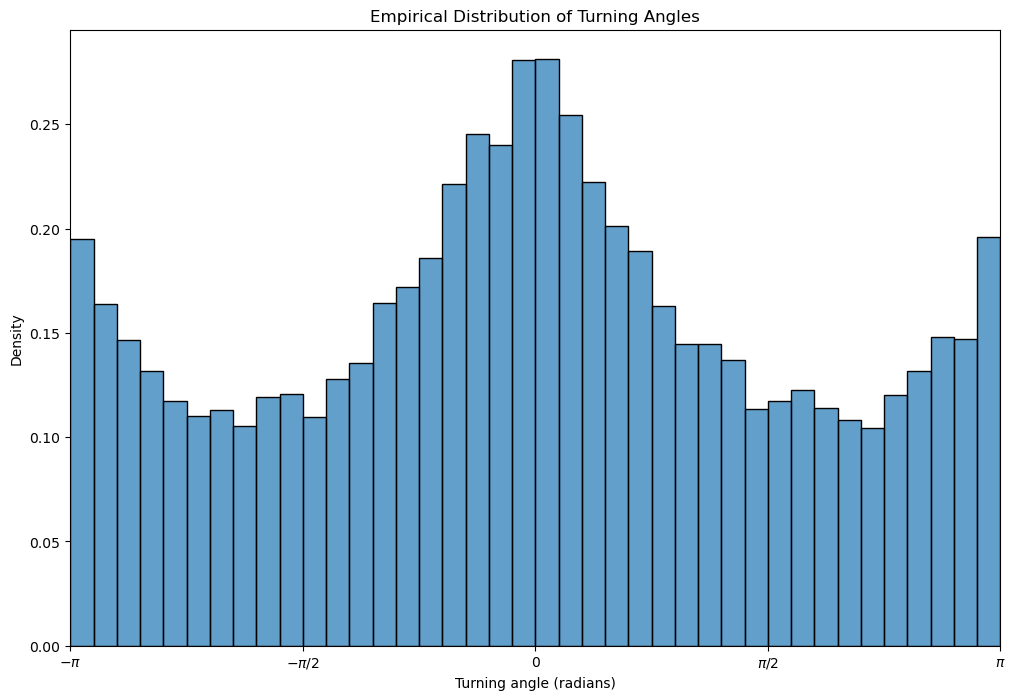

In [37]:
fig, ax = plt.subplots(figsize=(12, 8))
sns.histplot(correct_angles, x = "turn_angle", binwidth = np.pi / 20, stat="density", edgecolor="black", alpha=0.7)

ax.set_xlim(-np.pi, np.pi)
ax.set_xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
ax.set_xticklabels([r"$-\pi$", r"$-\pi/2$", "0", r"$\pi/2$", r"$\pi$"])

ax.set_xlabel("Turning angle (radians)")
# ax.set_ylabel("Density")
ax.set_title("Empirical Distribution of Turning Angles")
plt.show()

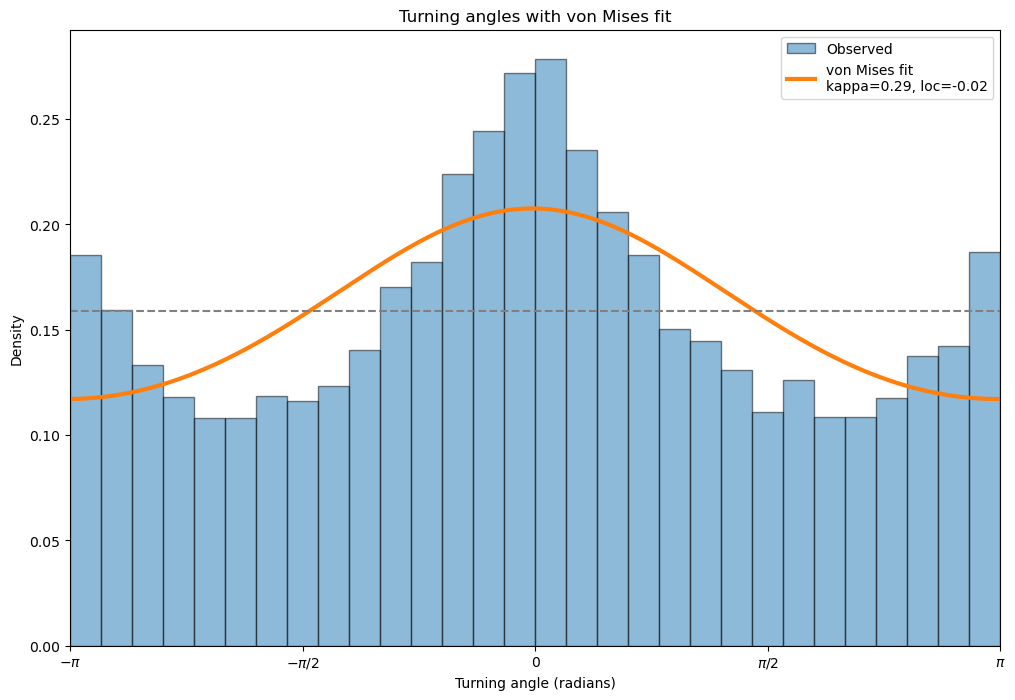

In [38]:
angles = correct_angles["turn_angle"].dropna().to_numpy()

kappa, loc, scale = stats.vonmises.fit(angles, fscale=1)

xx = np.linspace(-np.pi, np.pi, 1000)
yy = stats.vonmises.pdf(xx, kappa, loc=loc, scale=scale)

fig, ax = plt.subplots(figsize=(12, 8))

ax.hist(angles, bins=30, density=True, edgecolor="black", alpha=0.5, label="Observed")
ax.plot(xx, yy, lw=3, label=f"von Mises fit\nkappa={kappa:.2f}, loc={loc:.2f}")

ax.set_xlim(-np.pi, np.pi)
ax.set_xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
ax.set_xticklabels([r"$-\pi$", r"$-\pi/2$", "0", r"$\pi/2$", r"$\pi$"])

uniform_density = 1 / (2 * np.pi)
ax.axhline(uniform_density, linestyle="--", color="gray")

ax.set_xlabel("Turning angle (radians)")
ax.set_ylabel("Density")
ax.set_title("Turning angles with von Mises fit")
ax.legend()
plt.show()

In [39]:
import numpy as np

R = np.mean(np.cos(angles)) 
R

np.float64(0.1416027684659106)

In [40]:
import numpy as np
from scipy.stats import vonmises
from scipy.optimize import minimize

def vm_uniform_nll(params, angles):
    kappa, w = params
    
    # constraints
    if kappa < 0 or not (0 <= w <= 1):
        return np.inf
    
    vm = vonmises.pdf(angles, kappa, loc=0)
    uniform = 1 / (2 * np.pi)
    
    mixture = w * vm + (1 - w) * uniform
    
    # avoid log(0)
    mixture = np.clip(mixture, 1e-12, None)
    
    return -np.sum(np.log(mixture))

In [41]:
angles = correct_angles["turn_angle"].dropna().to_numpy()

init = [0.5, 0.5]  # kappa, w

res = minimize(vm_uniform_nll, init, args=(angles,),
               bounds=[(1e-6, None), (0, 1)])

kappa_hat, w_hat = res.x

print("kappa:", kappa_hat)
print("w (directed fraction):", w_hat)

kappa: 4.282219719798887
w (directed fraction): 0.18418697942705647


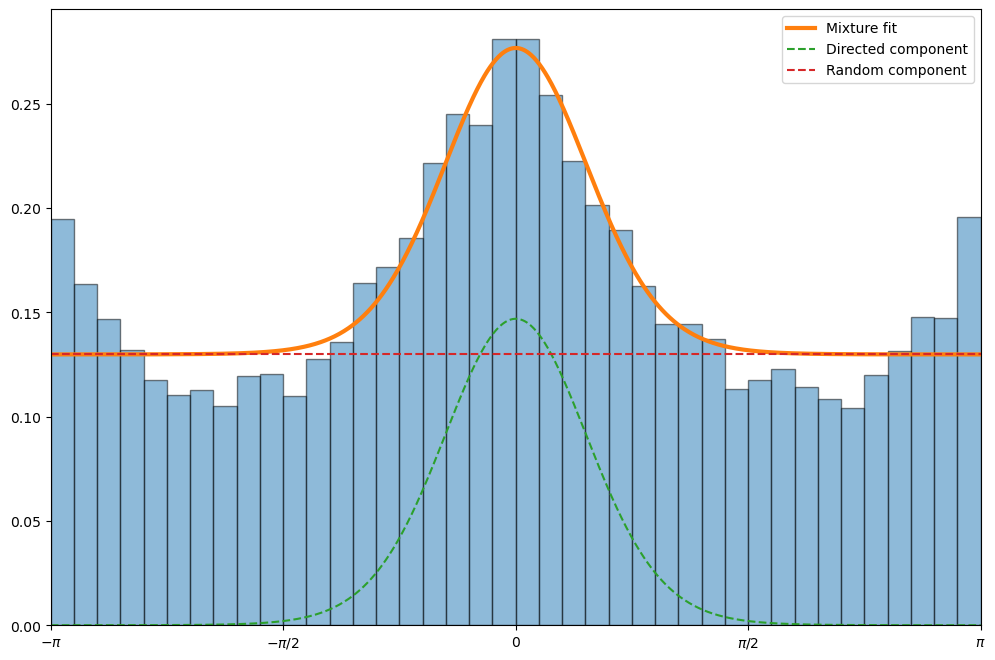

In [42]:
import matplotlib.pyplot as plt

xx = np.linspace(-np.pi, np.pi, 1000)

vm = vonmises.pdf(xx, kappa_hat, loc=0)
uniform = 1 / (2 * np.pi)

mixture = w_hat * vm + (1 - w_hat) * uniform

fig, ax = plt.subplots(figsize=(12, 8))

ax.hist(angles, bins=40, density=True, alpha=0.5, edgecolor="black")
ax.plot(xx, mixture, lw=3, label="Mixture fit")
ax.plot(xx, w_hat * vm, "--", label="Directed component")
ax.plot(xx, (1 - w_hat) * uniform * np.ones_like(xx), "--", label="Random component")

ax.set_xlim(-np.pi, np.pi)
ax.set_xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
ax.set_xticklabels([r"$-\pi$", r"$-\pi/2$", "0", r"$\pi/2$", r"$\pi$"])

ax.legend()
plt.show()

In [ ]:
correct_angles

In [ ]:
def estimate_turning_distribution(id, angles):
    angles = angles.dropna().to_numpy()
    init = [0.5, 0.5] 
    res = minimize(vm_uniform_nll, init, args=(angles,),
                bounds=[(1e-6, None), (0, 1)])
    kappa_hat, w_hat = res.x
    return {"ID": id, "kappa": kappa_hat, "w": w_hat}

per_individual = []
for id, subset in correct_angles.groupby("ID"):
    results  = estimate_turning_distribution(id, subset["turn_angle"])
    per_individual.append(results)

per_individual = pd.DataFrame(per_individual)

In [ ]:
print(per_individual)

### Combining the diffusive and advective component

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

df_plot = correct_angles[correct_angles["step_m"] < 8000].copy()
df_plot["abs_turn_angle"] = np.abs(df_plot["turn_angle"])

fig, ax = plt.subplots(figsize=(10, 7))
hb = ax.hexbin(
    df_plot["step_m"],
    df_plot["abs_turn_angle"],
    gridsize=40,
    mincnt=1
)
fig.colorbar(hb, ax=ax, label="Count")

ax.set_xlabel("Step length (m)")
ax.set_ylabel("Absolute turning angle (rad)")
ax.set_yticks([0, np.pi/2, np.pi])
ax.set_yticklabels(["0", r"$\pi/2$", r"$\pi$"])
ax.set_title("Joint distribution of step length and absolute turning angle")
plt.show()

In [ ]:
df_plot["step_bin"] = pd.qcut(df_plot["step_m"], q=10, duplicates="drop")

summary = (
    df_plot.groupby("step_bin", observed=True)
    .agg(
        step_median=("step_m", "median"),
        angle_median=("abs_turn_angle", "median"),
        angle_q25=("abs_turn_angle", lambda x: np.nanquantile(x, 0.25)),
        angle_q75=("abs_turn_angle", lambda x: np.nanquantile(x, 0.75)),
    )
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 7))
ax.plot(summary["step_median"], summary["angle_median"], marker="o")
ax.fill_between(
    summary["step_median"],
    summary["angle_q25"],
    summary["angle_q75"],
    alpha=0.2
)
ax.set_xscale("log")
ax.set_xlabel("Step length (m)")
ax.set_ylabel("Absolute turning angle (rad)")
ax.set_yticks([0, np.pi/2, np.pi])
ax.set_yticklabels(["0", r"$\pi/2$", r"$\pi$"])
ax.set_title("Turning-angle concentration as a function of step length")
plt.show()

### Fit HMM